In [257]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [258]:
ticker='BTC-USD'
date="2025-7-30"
end="2025-09-30"
df=yf.download(ticker,start=date,end=end)
df.columns=[i[0] for i in df.columns]
df['Pct_Change']=df['Close'].pct_change()
df.dropna(inplace=True)
df['adj']=((df['Close']+df['Close'].shift(1))/2)
#df.to_csv("C:/Users/user/Desktop/Jbooks/venv/data.csv",index=True)

C:\Users\user\AppData\Local\Temp\ipykernel_9388\4068163859.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,start=date,end=end)
[*********************100%***********************]  1 of 1 completed


In [259]:
x=pd.read_csv("C:/Users/user/Desktop/Jbooks/venv/data.csv",index_col=0)

In [260]:
last_date = x.index[-1]
new_dates = pd.date_range(start=pd.to_datetime(last_date) + pd.Timedelta(days=1), periods=1,freq="1d")
new_rows = pd.DataFrame({
    "Open": [0]*1,
    "High": [0]*1,
    "Low": [0]*1,
    "Close": [np.nan]*1,
    'Pct_Change':[0]*1,
    'adj':[0]*1,
    "Volume": [0]*1,
    "Date": new_dates
})
new_rows = new_rows.astype(x.reset_index().dtypes.to_dict())
x = pd.concat([x.reset_index(),new_rows], ignore_index=True)
x = x.set_index("Date")
x.loc[x.index[-1:], "Open"]=df['Close'].tail(1).values[0]

In [261]:
def flexible_rsi(series):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(window=8,center=True).mean()
    roll_down = down.rolling(window=8,center=True).mean()
    rs = roll_up / roll_down
    rsi = 100 - (100 / (1 + rs))
    rsi_scaled = (100 - (100 / (1 + rs)))/100
    return rsi_scaled
prices =x.Open
rsi_flex = flexible_rsi(prices)
x['Positions']=rsi_flex.shift(2)

In [262]:
x['Pct_Change']=x['Open'].pct_change()
x.tail(6)

,Close,High,Low,Open,Volume,Pct_Change,adj,Positions
Date,,,,,,,,
2025-09-09,111530.546875,113225.437500,110776.703125,112077.578125,45984480722,0.008227,111800.988281,0.679480
2025-09-10,113955.359375,114275.250000,110940.078125,111531.250000,56377473784,-0.004875,112742.953125,0.702036
2025-09-11,115507.539062,115522.546875,113453.835938,113961.429688,45685065332,0.021789,114731.449219,0.740583
2025-09-12,116101.578125,116769.382812,114794.484375,115507.789062,54785725894,0.013569,115804.558594,0.859841
2025-09-13,115784.304688,116310.382812,115727.804688,116104.312500,49345486848,0.005164,115942.941406,0.838388
2025-09-14 00:00:00,NaN,0.000000,0.000000,115840.531250,0,-0.002272,0.000000,NaN


In [263]:
df.tail(5)

,Close,High,Low,Open,Volume,Pct_Change,adj
Date,,,,,,,
2025-09-09,111530.546875,113225.437500,110776.703125,112077.578125,45984480722,-0.004826,111800.988281
2025-09-10,113955.359375,114275.250000,110940.078125,111531.250000,56377473784,0.021741,112742.953125
2025-09-11,115507.539062,115522.546875,113453.835938,113961.429688,45685065332,0.013621,114731.449219
2025-09-12,116101.578125,116769.382812,114794.484375,115507.789062,54785725894,0.005143,115804.558594
2025-09-13,115840.531250,116310.382812,115727.804688,116104.312500,43709415424,-0.002248,115971.054688


<Axes: xlabel='Date'>

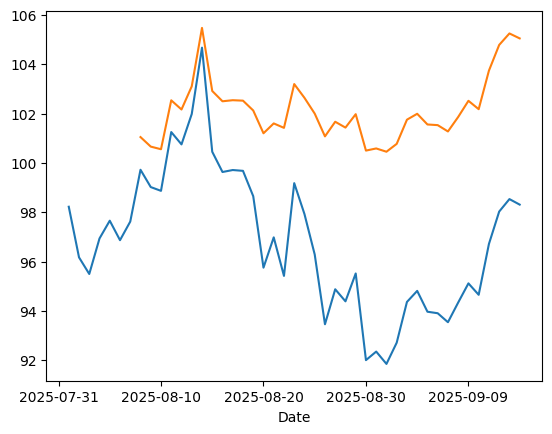

In [264]:
(100*(1+x['Pct_Change']).cumprod()).plot()
(100*(1+(x['Positions'].shift(1)*x['Pct_Change'])).cumprod()).plot()

<Axes: xlabel='Date'>

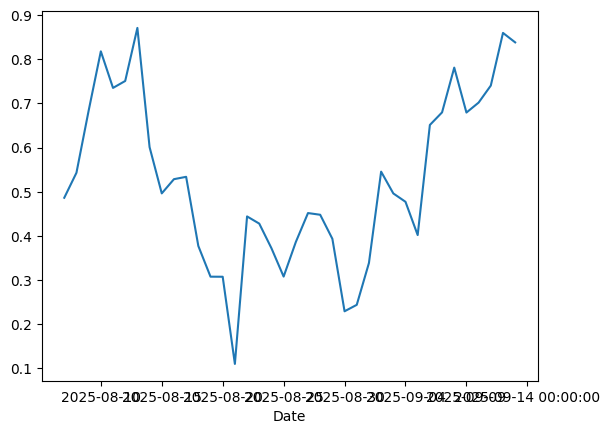

In [265]:
x['Positions'].plot()

In [266]:
x['Positions'].max()#.tail(100).plot()

np.float64(0.8711357819218015)

In [267]:
x['Positions'].min()

np.float64(0.11022597497605674)

In [268]:
(100*(1+(x['Positions'].shift(1)*x['Pct_Change'])).cumprod())

Date
2025-07-31                    NaN
2025-08-01                    NaN
2025-08-02                    NaN
2025-08-03                    NaN
2025-08-04                    NaN
2025-08-05                    NaN
2025-08-06                    NaN
2025-08-07                    NaN
2025-08-08             101.046940
2025-08-09             100.660560
2025-08-10             100.554050
2025-08-11             102.537616
2025-08-12             102.165319
2025-08-13             103.103282
2025-08-14             105.472926
2025-08-15             102.915821
2025-08-16             102.498283
2025-08-17             102.541835
2025-08-18             102.523717
2025-08-19             102.124464
2025-08-20             101.201293
2025-08-21             101.600756
2025-08-22             101.420244
2025-08-23             103.196566
2025-08-24             102.637640
2025-08-25             101.998413
2025-08-26             101.075511
2025-08-27             101.668176
2025-08-28             101.431210
2025-08-2

In [269]:
(100*(1+x['Pct_Change']).cumprod())

Date
2025-07-31                    NaN
2025-08-01              98.222341
2025-08-02              96.169818
2025-08-03              95.495490
2025-08-04              96.936604
2025-08-05              97.656488
2025-08-06              96.866159
2025-08-07              97.620732
2025-08-08              99.721529
2025-08-09              99.019499
2025-08-10              98.866271
2025-08-11             101.250220
2025-08-12             100.750237
2025-08-13             101.981899
2025-08-14             104.672491
2025-08-15             100.451610
2025-08-16              99.630656
2025-08-17              99.710742
2025-08-18              99.677743
2025-08-19              98.649135
2025-08-20              95.751969
2025-08-21              96.980535
2025-08-22              95.417354
2025-08-23              99.179126
2025-08-24              97.923986
2025-08-25              96.285666
2025-08-26              93.457274
2025-08-27              94.875893
2025-08-28              94.386511
2025-08-2